In [1]:
import os
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import matplotlib.pyplot as plt
import orbax.checkpoint as ocp
import tensorstore as ts
jr.init_cluster()

#parameters
nx = 128
ny = 128
nz = 128
Lx = 2.0 * jnp.pi
Ly = 2.0 * jnp.pi
Lz = 2.0 * jnp.pi
t = 0.0
nsnap = 100
t_snap = 10.0
t_end = 10.0
cfl_safety = 0.5 
spatial_dimensions=3
snap_path="/Users/alfy/jax_scratch/ot3d"

#we will use hyperviscosity
visc=1e-9
res=1e-9
hyper=3

#mngr=jr.snapshot_manager_setup(snap_path=snap_path,nsnap=nsnap)

#prepare necessary objects for simulation
params=jr.Parameters(nx=nx,ny=ny,nz=nz,Lx=Lx,Ly=Ly,Lz=Lz,diss=(visc,res),hyper=hyper,cfl_safety=cfl_safety,dims=spatial_dimensions)
kgrid = jr.setup_kgrids(params)

rmhd-solver has initialized jax in 64bit precision.
Running in local mode. Total devices: 1


In [20]:
import orbax.checkpoint as ocp
from jax_rmhd.snapshot_io import get_precision_types
ckptr = ocp.AsyncCheckpointer(ocp.StandardCheckpointHandler())
ckpt_path = os.path.abspath(snap_path+"/"+str(1)+"/default")

In [21]:
if params.spatial_dimensions==3:
    shape_complex = (params.nfields,params.nz, params.nx, params.ny // 2 + 1)
else:
    shape_complex = (params.nx, params.ny // 2 + 1)
ftype, ctype = get_precision_types()
fields_like = jax.ShapeDtypeStruct(shape_complex, ctype,sharding=params.fields_sharding)
state_like = jr.SimulationState(t=jax.ShapeDtypeStruct((), ftype), fields=fields_like)

In [22]:
restored=ckptr.restore(ckpt_path,args=ocp.args.StandardRestore(state_like))

ValueError: Topology mismatch detected. The checkpoint was saved with a different topology than the current one. Please provide a target tree with the desired topology to restore.

In [24]:
help(ckptr)

Help on AsyncCheckpointer in module orbax.checkpoint._src.checkpointers.async_checkpointer object:

class AsyncCheckpointer(orbax.checkpoint._src.checkpointers.checkpointer.Checkpointer)
 |  AsyncCheckpointer(handler: orbax.checkpoint._src.handlers.async_checkpoint_handler.AsyncCheckpointHandler, timeout_secs: Optional[int] = None, *, async_options: orbax.checkpoint.options.AsyncOptions = AsyncOptions(timeout_secs=1200, barrier_sync_fn=None, post_finalization_callback=None, create_directories_asynchronously=True), multiprocessing_options: orbax.checkpoint.options.MultiprocessingOptions = MultiprocessingOptions(primary_host=0, active_processes=None, barrier_sync_key_prefix=None), file_options: orbax.checkpoint.options.FileOptions = FileOptions(path_permission_mode=None), checkpoint_metadata_store: Optional[orbax.checkpoint._src.metadata.checkpoint.MetadataStore] = None, temporary_path_class: Optional[Type[orbax.checkpoint._src.path.atomicity_types.TemporaryPath]] = None)
 |  
 |  An asy

In [2]:
from jax_rmhd.snapshot_io import load_snapshot,snapshot_manager_setup
mngr=snapshot_manager_setup(snap_path,1000)
s=load_snapshot(1,mngr,params)

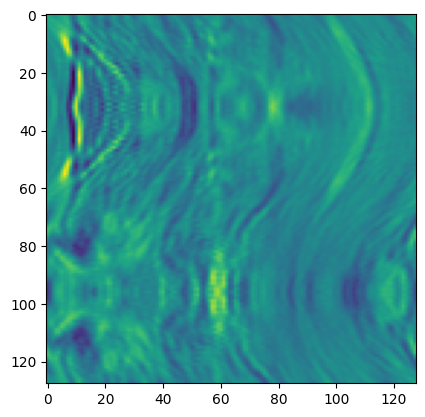

In [6]:
vort=ft.irfft2(-kgrid.ksq()*s.fields[0,:,:,:])
plt.imshow(vort[:,:,0])